C:\Users\escaw\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:26:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


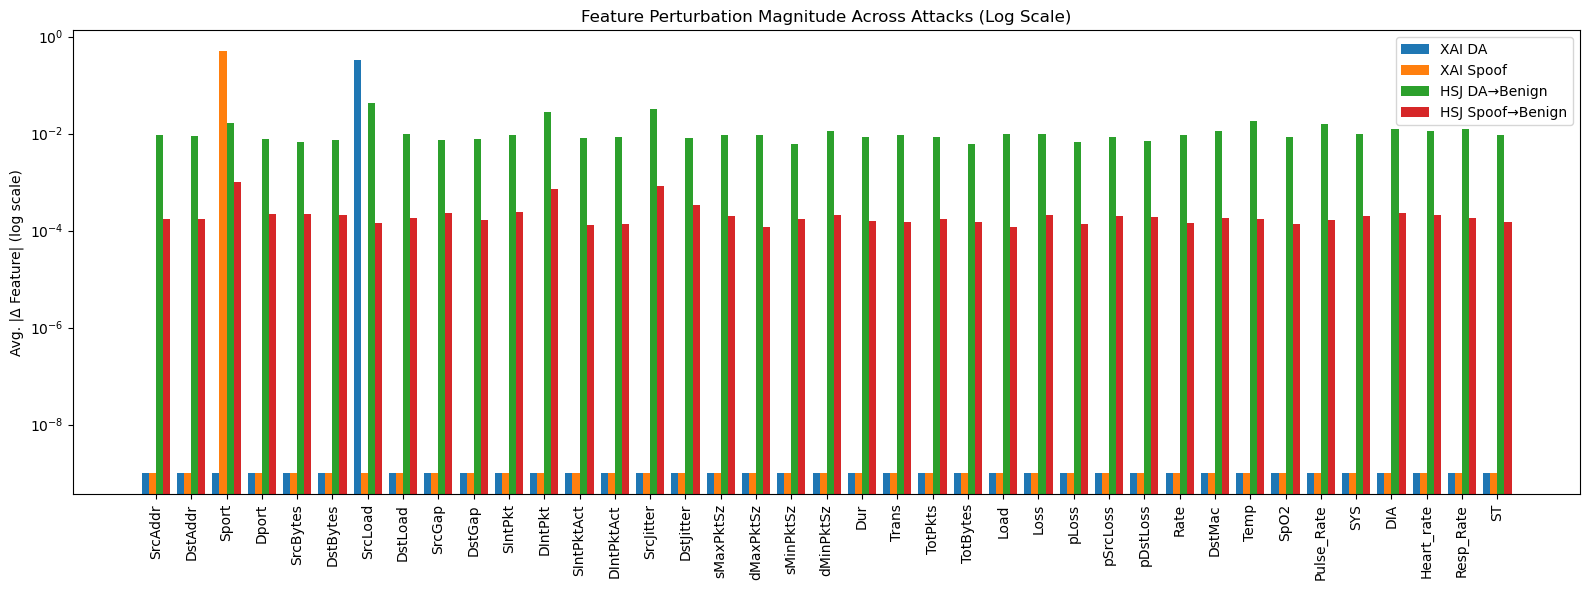

=== Clean (baseline) ===
Clean overall acc: 97.40%
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263



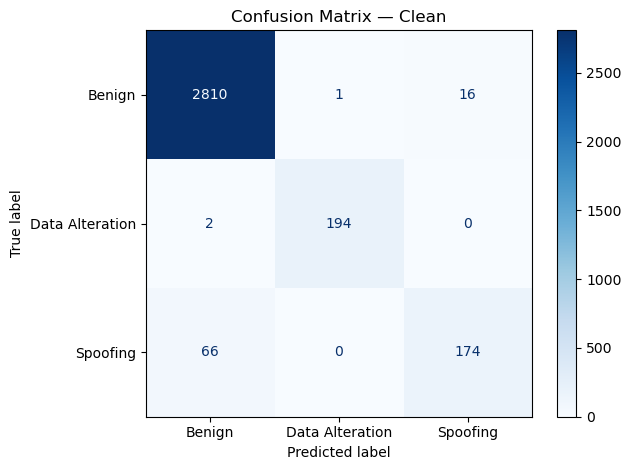

=== XAI‑driven Data Alteration ===
XAI DA overall acc: 91.45%
  Misclassification on targeted samples: 100.00%
                 precision    recall  f1-score   support

         Benign       0.91      0.99      0.95      2827
Data Alteration       0.00      0.00      0.00       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.91      3263
      macro avg       0.61      0.57      0.59      3263
   weighted avg       0.86      0.91      0.88      3263



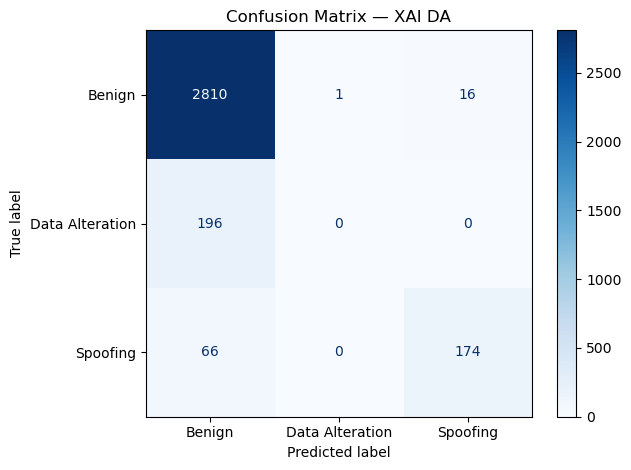

=== XAI‑driven Spoofing ===
XAI Spoof overall acc: 93.14%
  Misclassification on targeted samples: 85.42%
                 precision    recall  f1-score   support

         Benign       0.93      0.99      0.96      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.69      0.15      0.24       240

       accuracy                           0.93      3263
      macro avg       0.87      0.71      0.73      3263
   weighted avg       0.92      0.93      0.91      3263



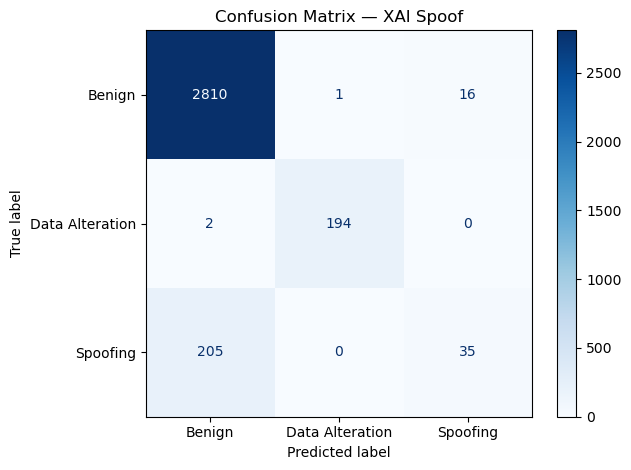

=== HSJ Data Alteration → Benign ===
HSJ DA→Benign overall acc: 91.45%
  Misclassification on targeted samples: 100.00%
                 precision    recall  f1-score   support

         Benign       0.91      0.99      0.95      2827
Data Alteration       0.00      0.00      0.00       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.91      3263
      macro avg       0.61      0.57      0.59      3263
   weighted avg       0.86      0.91      0.88      3263



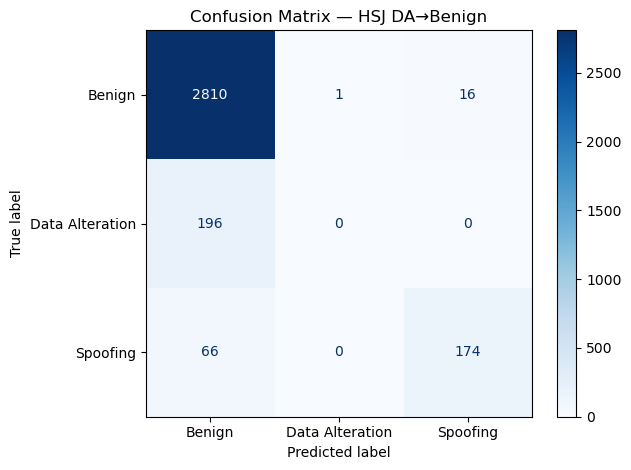

=== HSJ Spoofing → Benign ===
HSJ Spoof→Benign overall acc: 92.06%
  Misclassification on targeted samples: 100.00%
                 precision    recall  f1-score   support

         Benign       0.92      0.99      0.96      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.00      0.00      0.00       240

       accuracy                           0.92      3263
      macro avg       0.64      0.66      0.65      3263
   weighted avg       0.86      0.92      0.89      3263



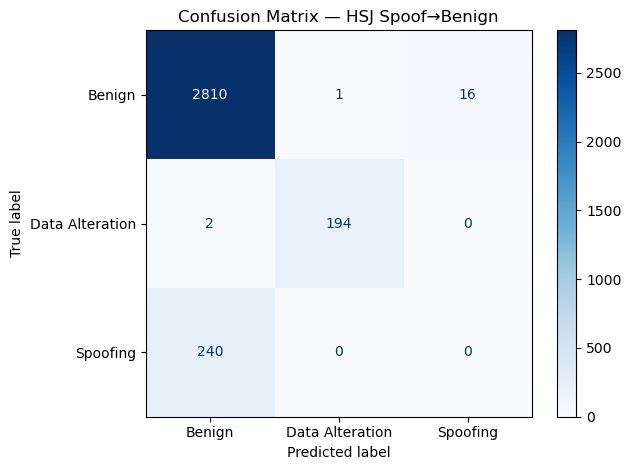

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from art.estimators.classification import XGBoostClassifier
from art.attacks.evasion import HopSkipJump

# 1. Load & preprocess
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac','Dir','Label','Flgs','Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)

# Encode attack labels separately
le_y = LabelEncoder()
df['y'] = le_y.fit_transform(df['Attack Category'])
df.drop(columns=['Attack Category'], inplace=True)

# Encode other categoricals
for col in ['DstMac','SrcAddr','DstAddr','Sport']:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns='y')
y = df['y']

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler   = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 2. Train XGBoost
num_classes = len(le_y.classes_)
model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False
)
model.fit(X_trainN, y_train)

# Wrap for ART
art_model = XGBoostClassifier(
    model=model,
    clip_values=(X_trainN.values.min(), X_trainN.values.max()),
    nb_classes=num_classes,
    nb_features=X_trainN.shape[1]
)

# Class indices
idx_da     = np.where(le_y.classes_ == 'Data Alteration')[0][0]
idx_spoof  = np.where(le_y.classes_ == 'Spoofing')[0][0]
idx_benign = np.where(le_y.classes_ == 'Benign')[0][0]

mask_da    = (y_test.values == idx_da)
mask_spoof = (y_test.values == idx_spoof)

# 3a. XAI-driven Data Alteration
sigma_load      = X_testN['SrcLoad'].std()
delta_da        = 0.33 * sigma_load
X_adv_xai_da    = X_testN.copy()
X_adv_xai_da.loc[mask_da, 'SrcLoad'] += delta_da

# 3b. XAI-driven Spoofing
sigma_sport     = X_testN['Sport'].std()
delta_spoof     = 0.5 * sigma_sport
X_adv_xai_spoof = X_testN.copy()
X_adv_xai_spoof.loc[mask_spoof, 'Sport'] += delta_spoof

# 3c. HSJ on DA → Benign
X_target_da = X_testN.to_numpy()[mask_da]
y_target_da = np.zeros((X_target_da.shape[0], num_classes), dtype=int)
y_target_da[:, idx_benign] = 1

hsj_da = HopSkipJump(
    classifier=art_model,
    targeted=True,
    max_iter=10, max_eval=1000, init_eval=10, verbose=False
)
x_adv_part_da = hsj_da.generate(x=X_target_da, y=y_target_da)

x_adv_hsj_da = X_testN.to_numpy().copy()
x_adv_hsj_da[mask_da] = x_adv_part_da

# 3d. HSJ on Spoofing → Benign
X_target_sp = X_testN.to_numpy()[mask_spoof]
y_target_sp = np.zeros((X_target_sp.shape[0], num_classes), dtype=int)
y_target_sp[:, idx_benign] = 1

hsj_sp = HopSkipJump(
    classifier=art_model,
    targeted=True,
    max_iter=10, max_eval=1000, init_eval=10, verbose=False
)
x_adv_part_sp = hsj_sp.generate(x=X_target_sp, y=y_target_sp)

x_adv_hsj_sp = X_testN.to_numpy().copy()
x_adv_hsj_sp[mask_spoof] = x_adv_part_sp

# 4. Compute avg. |Δ| per feature
def mean_abs_delta(orig, adv, mask):
    d = adv - orig
    return np.mean(np.abs(d[mask]), axis=0)

orig_arr = X_testN.to_numpy()
mean_da     = mean_abs_delta(orig_arr, X_adv_xai_da.to_numpy(), mask_da)
mean_sp     = mean_abs_delta(orig_arr, X_adv_xai_spoof.to_numpy(), mask_spoof)
mean_hsj_da = mean_abs_delta(orig_arr, x_adv_hsj_da, mask_da)
mean_hsj_sp = mean_abs_delta(orig_arr, x_adv_hsj_sp, mask_spoof)

# 5. Plot comparison with log scale
features = X.columns
x = np.arange(len(features))
w = 0.20

plt.figure(figsize=(16,6))
plt.bar(x - 1.5*w, mean_da + 1e-9,     width=w, label='XAI DA')
plt.bar(x - 0.5*w, mean_sp + 1e-9,     width=w, label='XAI Spoof')
plt.bar(x + 0.5*w, mean_hsj_da + 1e-9, width=w, label='HSJ DA→Benign')
plt.bar(x + 1.5*w, mean_hsj_sp + 1e-9, width=w, label='HSJ Spoof→Benign')

plt.xticks(x, features, rotation=90)
plt.yscale('log')
plt.ylabel('Avg. |Δ Feature| (log scale)')
plt.title('Feature Perturbation Magnitude Across Attacks (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Print metrics & plot confusion matrices
def evaluate_and_plot(name, X_adv, mask=None):
    y_pred = model.predict(X_adv)
    acc     = accuracy_score(y_test, y_pred)
    mis     = np.nan if mask is None else np.mean(y_pred[mask] != y_test.values[mask])
    print(f"{name} overall acc: {acc:.2%}")
    if mask is not None:
        print(f"  Misclassification on targeted samples: {mis:.2%}")
    print(classification_report(y_test, y_pred, target_names=le_y.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_y.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# Scenarios
print("=== Clean (baseline) ===")
evaluate_and_plot("Clean", X_testN)

print("=== XAI‑driven Data Alteration ===")
evaluate_and_plot("XAI DA", X_adv_xai_da, mask_da)

print("=== XAI‑driven Spoofing ===")
evaluate_and_plot("XAI Spoof", X_adv_xai_spoof, mask_spoof)

print("=== HSJ Data Alteration → Benign ===")
evaluate_and_plot("HSJ DA→Benign", x_adv_hsj_da, mask_da)

print("=== HSJ Spoofing → Benign ===")
evaluate_and_plot("HSJ Spoof→Benign", x_adv_hsj_sp, mask_spoof)
